# **0) Environment check**

In [ ]:

import os
import numpy as np
import matplotlib.pyplot as plt

import cv2

from skimage import data

print("OpenCV:", cv2.__version__)

OpenCV: 4.13.0


Helper Fuctions (provided)

In [ ]:
def to_rgb(img_bgr_or_rgb):
    """Ensure image is RGB uint8."""
    if img_bgr_or_rgb is None:
        raise ValueError("Image is None. Check the path or loading step.")
    img = img_bgr_or_rgb
    if img.ndim == 2:
        return img
    # If it came from cv2.imread it's BGR; if from skimage it's RGB.
    # We detect by heuristic: assume cv2 format if loaded via cv2.imread.
    return img

def load_image(path=None):
    """Load an RGB image. If path is missing, fall back to a built-in sample."""
    if path and os.path.exists(path):
        bgr = cv2.imread(path, cv2.IMREAD_COLOR)
        if bgr is None:
            raise ValueError(f"Failed to read: {path}")
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        return rgb
    # offline sample (RGB)
    return data.astronaut()

def show_side_by_side(img1, img2, title1="Image 1", title2="Image 2", cmap1=None, cmap2=None):
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1); plt.imshow(img1, cmap=cmap1); plt.title(title1); plt.axis('off')
    plt.subplot(1,2,2); plt.imshow(img2, cmap=cmap2); plt.title(title2); plt.axis('off')
    plt.axis('off')
    plt.show()

def clip_uint8(x):
    """Clip and convert to uint8."""
    return np.clip(x, 0, 255).astype(np.uint8)

# **1) Load an image**

Image shape (H, W, C): (171, 294, 3) | dtype: uint8


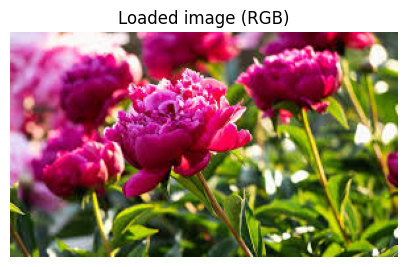

In [ ]:
IMAGE_PATH = 'flower.jpeg'

img = load_image(IMAGE_PATH)
print("Image shape (H, W, C):", img.shape, "| dtype:", img.dtype)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title("Loaded image (RGB)")
plt.axis("off")
plt.show()

# **2) Image I/O basics**

**Task 2.1 — Inspect pixels**



In [ ]:
h, w = img.shape[:2]
print("Top-left pixel:", img[0, 0])
print("Center pixel:", img[h//2, w//2])

Top-left pixel: [228 218 242]
Center pixel: [158   9  41]


**Task 2.1 (Answer):**

The printed pixel values are arrays of three numbers, for example [R, G, B].
In an RGB image, the three numbers represent the intensity of the Red, Green, and Blue channels, respectively.
Each value ranges from 0 to 255 (uint8 format), where:
0 means no intensity of that color
255 means maximum intensity
Together, these three values define the final color of the pixel.

**Task 2.2 — Save and re-load**

Reloaded shape: (171, 294, 3) | dtype: uint8


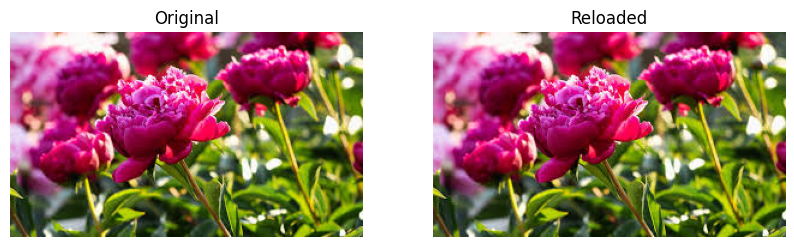

In [ ]:
out_path = "output_saved.png"

bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
cv2.imwrite(out_path, bgr)

reloaded_bgr = cv2.imread(out_path, cv2.IMREAD_COLOR)
reloaded_rgb = cv2.cvtColor(reloaded_bgr, cv2.COLOR_BGR2RGB)

print("Reloaded shape:", reloaded_rgb.shape, "| dtype:", reloaded_rgb.dtype)
show_side_by_side(img, reloaded_rgb, "Original", "Reloaded")

# **3) Grayscale and binary images**



Ta**sk 3.1 — Convert to grayscale**

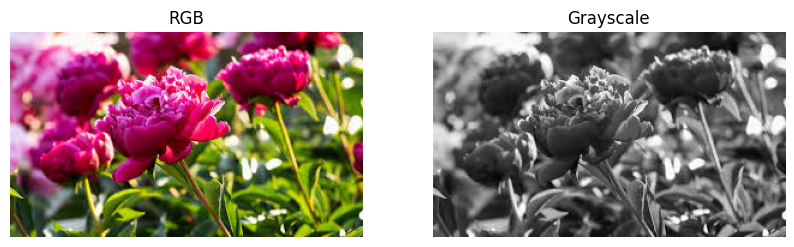

Gray shape: (171, 294) | dtype: uint8


In [ ]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
show_side_by_side(img, gray, "RGB", "Grayscale", cmap2="gray")
print("Gray shape:", gray.shape, "| dtype:", gray.dtype)

**Task 3.2 — Threshold to binary**

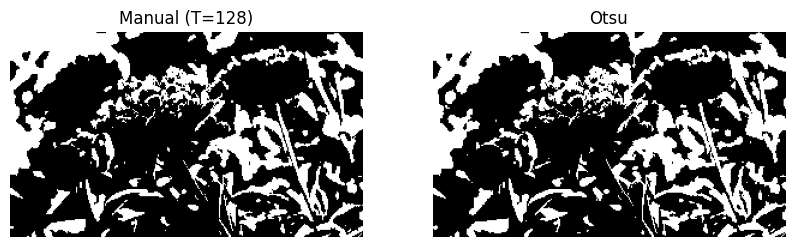

Otsu threshold chosen by OpenCV: 120.0


In [ ]:
th_manual = 128
_, binary_manual = cv2.threshold(gray, th_manual, 255, cv2.THRESH_BINARY)

_, binary_otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

show_side_by_side(binary_manual, binary_otsu, f"Manual (T={th_manual})", "Otsu", cmap1="gray", cmap2="gray")
print("Otsu threshold chosen by OpenCV:", _)

**Task 3.2 (Answer):**

The manual threshold uses a fixed value (e.g., 128), so all pixels above this value become white (255) and others become black (0).
Otsu’s method automatically computes an optimal threshold based on the image histogram. It usually produces a more balanced and adaptive result, especially when lighting conditions vary.
Otsu’s result generally separates foreground and background more effectively than a fixed manual threshold.

# **4) Cropping (ROI)**

**Task 4.1 — Crop a region of interest**



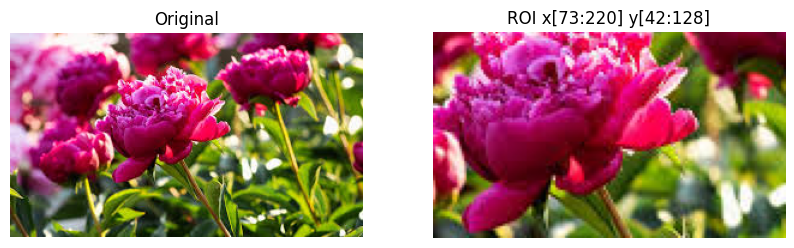

ROI shape: (86, 147, 3)


In [ ]:
h, w = img.shape[:2]
x1, y1 = int(0.25*w), int(0.25*h)
x2, y2 = int(0.75*w), int(0.75*h)

roi = img[y1:y2, x1:x2].copy()
show_side_by_side(img, roi, "Original", f"ROI x[{x1}:{x2}] y[{y1}:{y2}]")
print("ROI shape:", roi.shape)

**Task 4.2 — Explain coordinates(Answer):**

Images in NumPy are stored in row-major order, meaning the first index represents the row (y-coordinate) and the second index represents the column (x-coordinate).
Therefore, slicing is written as img[y, x] because:
y corresponds to vertical position (rows)
x corresponds to horizontal position (columns)
Using img[x, y] would incorrectly swap the axes and produce the wrong region.

# **5) Color spaces**

**Task 5.1 — Convert RGB to HSV and visualize channels**

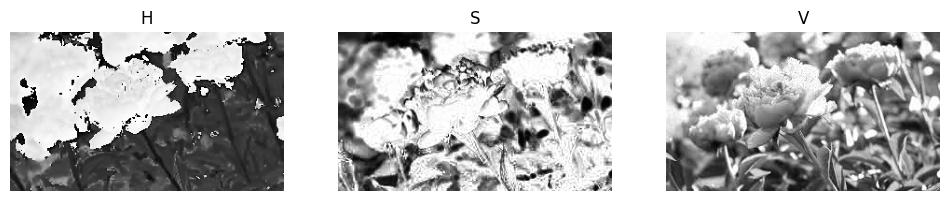

In [ ]:
hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
H, S, V = hsv[:,:,0], hsv[:,:,1], hsv[:,:,2]

plt.figure(figsize=(12,3))
for i, (ch, name) in enumerate([(H,"H"), (S,"S"), (V,"V")], start=1):
    plt.subplot(1,3,i); plt.imshow(ch, cmap="gray"); plt.title(name); plt.axis("off")
plt.show()

# **6) Lab 2 — Basic arithmetic operations on images**

**6.1 Subtracting an intensity (darkening)**

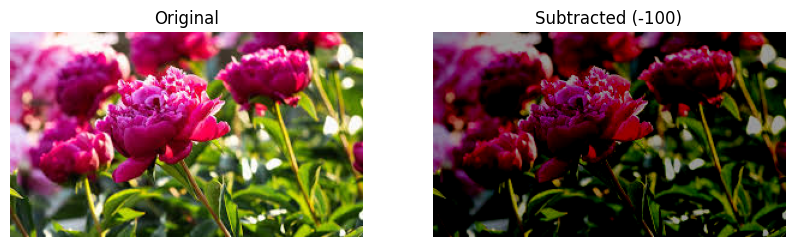

In [ ]:
sub_val = 100  # TODO: try 30, 100, 150
img_sub = cv2.subtract(img, sub_val)

show_side_by_side(img, img_sub, "Original", f"Subtracted (-{sub_val})")

**Task 6.1 (Answer):**

When sub_val increases, the image becomes progressively darker.
This happens because a constant value is subtracted from every pixel intensity. Since pixel values represent brightness levels (0–255), reducing them decreases brightness.
If the subtraction result goes below 0, OpenCV saturates it at 0, preventing negative values.

**6.2 Subtract from red channel only**

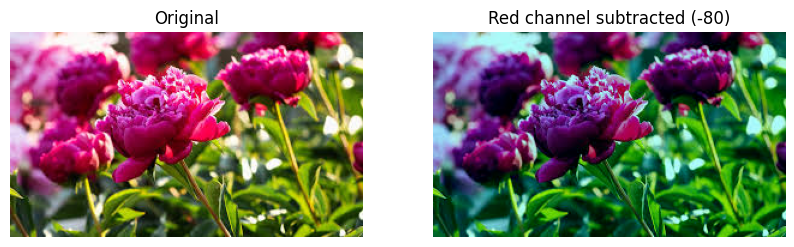

In [ ]:
sub_val_r = 80

img_red_only = img.copy()
# RGB: channel 0=R, 1=G, 2=B
img_red_only[:,:,0] = cv2.subtract(img_red_only[:,:,0], sub_val_r)

show_side_by_side(img, img_red_only, "Original", f"Red channel subtracted (-{sub_val_r})")


**6.3 Adding an intensity (brightening)**

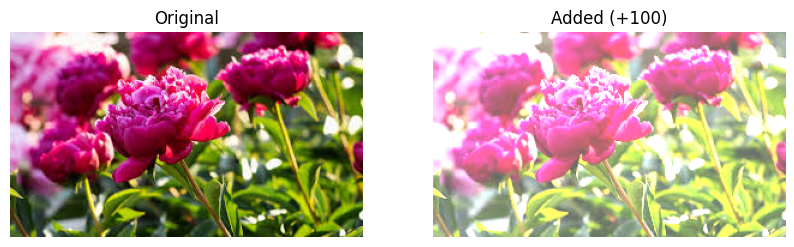

In [ ]:
add_val = 100  # TODO: try 30, 100, 150
img_add = cv2.add(img, add_val)

show_side_by_side(img, img_add, "Original", f"Added (+{add_val})")

**Task 6.3 (Answer):**

When add_val increases, the image becomes brighter.
This happens because a constant value is added to all pixel intensities, increasing brightness.
If values exceed 255, OpenCV saturates them at 255, preventing overflow.

**6.4 Add to red channel only**

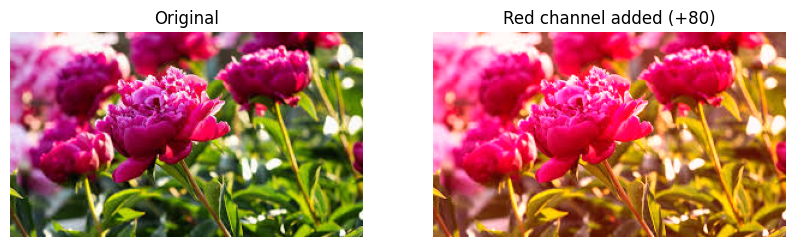

In [ ]:
add_val_r = 80

img_red_only_add = img.copy()
img_red_only_add[:,:,0] = cv2.add(img_red_only_add[:,:,0], add_val_r)

show_side_by_side(img, img_red_only_add, "Original", f"Red channel added (+{add_val_r})")


**6.5 Multiplying by a constant (contrast/brightness change)**

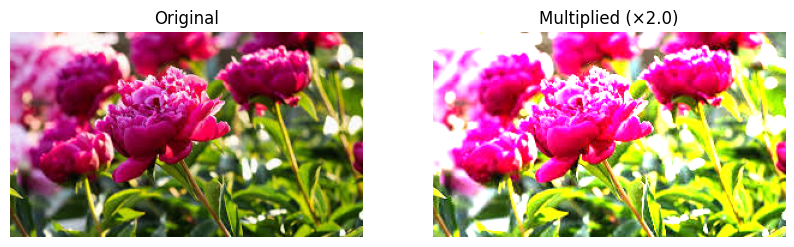

In [ ]:
factor = 2.0

img_f = img.astype(np.float32)
img_mul = clip_uint8(img_f * factor)

show_side_by_side(img, img_mul, "Original", f"Multiplied (×{factor})")

**Task 6.5 (Answer):**

Multiplying by a factor greater than 1 increases brightness and contrast. However, if the factor is too large, many pixel values saturate at 255, causing loss of detail in bright regions.
Multiplying by a factor less than 1 reduces brightness, making the image darker.
Thus, multiplication acts as a scaling operation that affects overall intensity and contrast.

**6.6 Dividing by a constant**

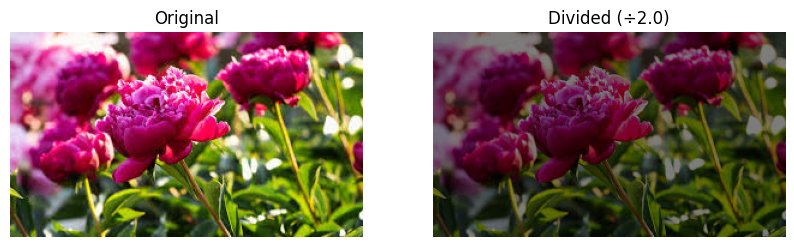

In [ ]:
divisor = 2.0

img_f = img.astype(np.float32)
img_div = clip_uint8(img_f / divisor)

show_side_by_side(img, img_div, "Original", f"Divided (÷{divisor})")


**Task 6.6 (Answer):**

Dividing by a number greater than 1 reduces pixel intensity, making the image darker.
Dividing by a number less than 1 increases intensity, making the image brighter. However, dividing by a value less than 1 can easily cause saturation (values exceeding 255 after clipping).
Division has a similar but inverse effect compared to multiplication.

# **7) Mini-report**

**Report:**

In this assignment, I learned the fundamental concepts of digital image processing using Python, NumPy, and OpenCV. I practiced loading and saving images, understanding image shape and data types, and inspecting pixel values. I learned that RGB images contain three channels representing red, green, and blue intensities, each ranging from 0 to 255.
Converting images to grayscale helped me understand how color information can be reduced to intensity values. I also applied manual thresholding and Otsu’s method to create binary images and observed how automatic threshold selection improves segmentation results.
Cropping using array slicing reinforced the concept that images use row-major indexing (y, x). In the color space section, I explored HSV representation and visualized individual channels, which showed how color information is separated from brightness.
The arithmetic operations section was particularly useful. I observed how addition and subtraction change brightness, while multiplication and division affect brightness and contrast. I also understood the importance of clipping and uint8 data types to avoid overflow or underflow issues.
One issue I encountered was remembering that OpenCV uses BGR format when reading/writing images, which required color conversion to RGB for correct display.